In [23]:
from PIL import Image, ImageDraw

In [24]:
image = Image.open('Пузыри.jpg').convert("RGB")
draw = ImageDraw.Draw(image)
w, h = image.size
pix = image.load()

### Преобразуем изображение в чёрно-белый формат

In [25]:
factor = 235
for i in range(0, w):
    for j in range(0, h):
        r, g, b = pix[i,j]
        S = r + g + b // 3
        if S > 127 + factor:
            r, g, b = (255, 255, 255)
        else:
            r, g, b = (0, 0, 0)
        draw.point((i, j), (r, g, b))

### Сохраним изображение в PNG, чтобы убрать артефакты JPEG

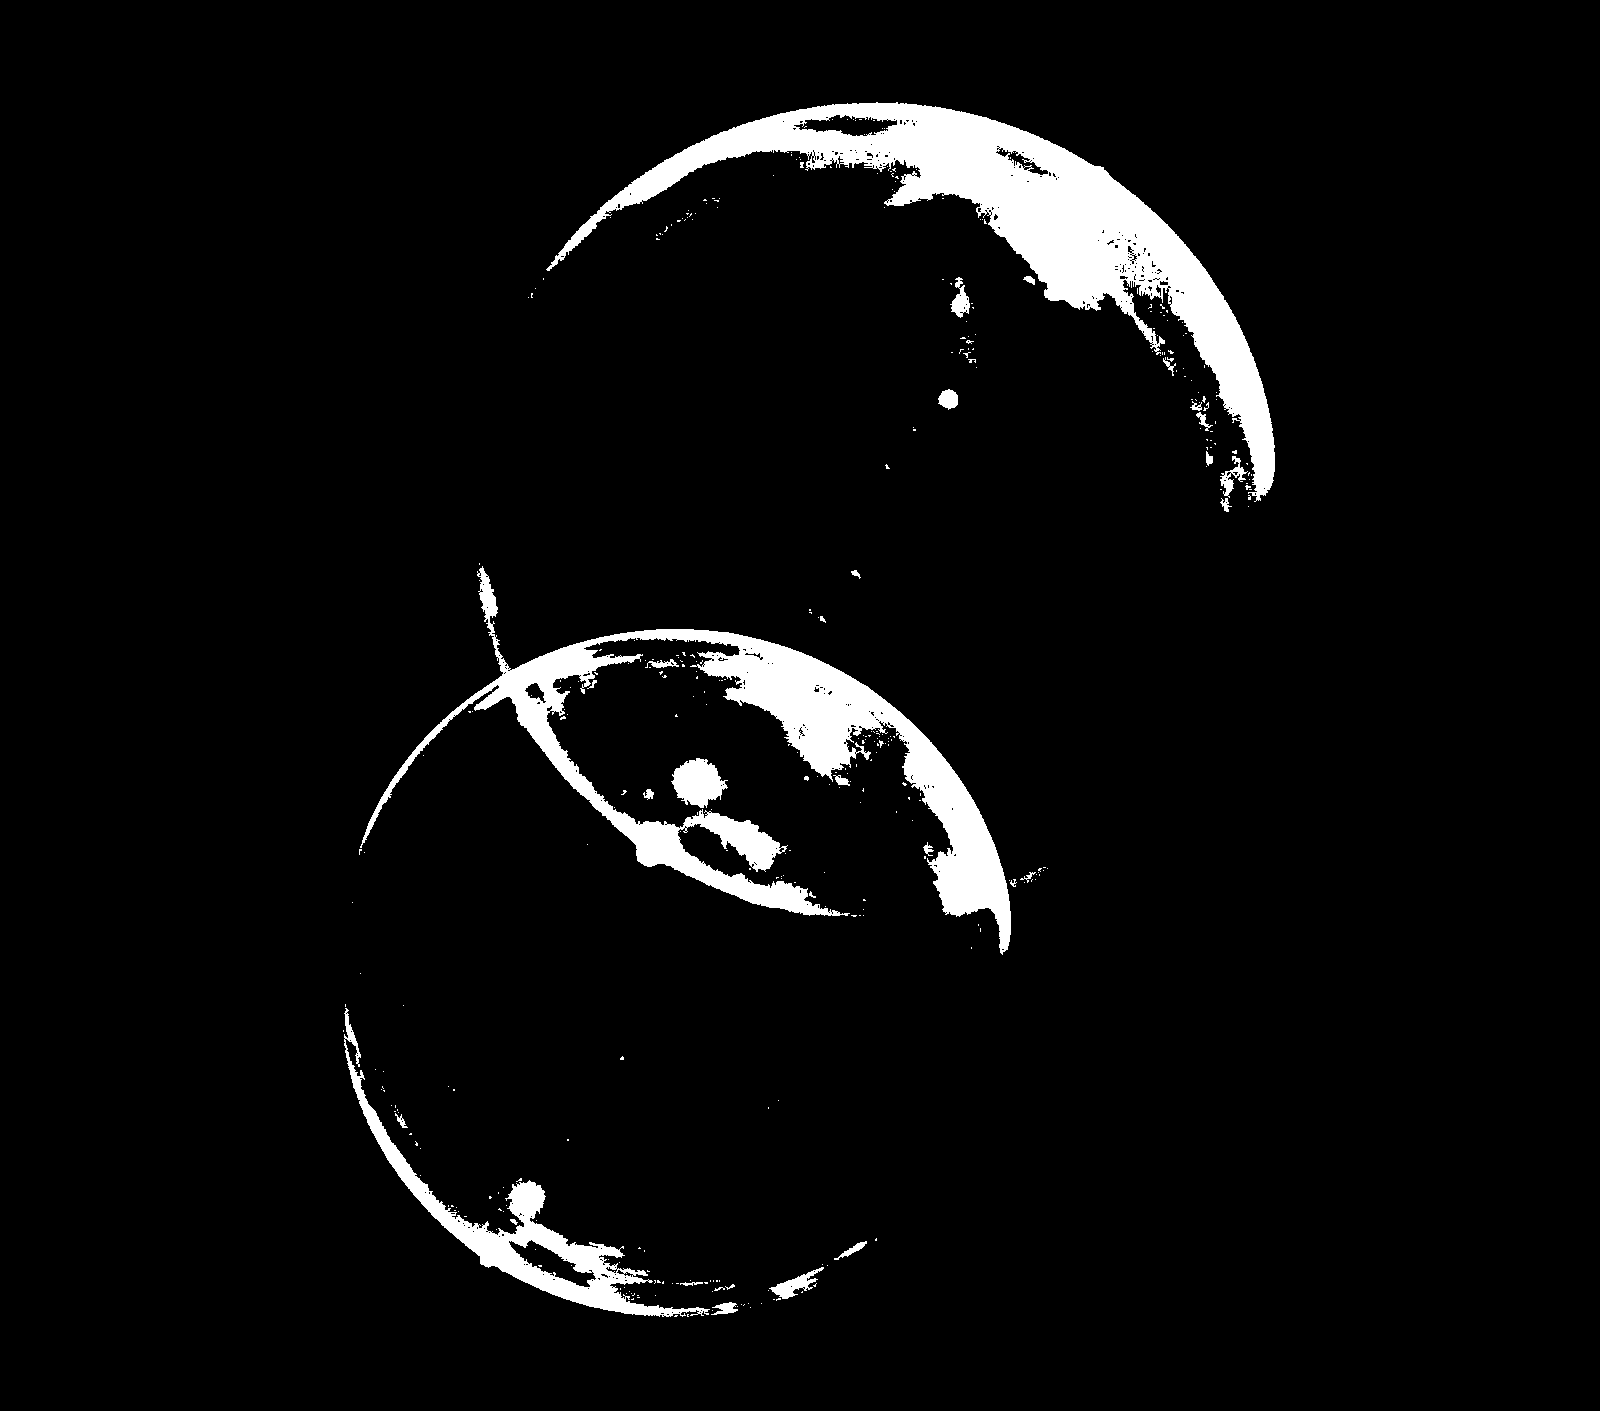

In [26]:
image.save('bubbles.png')
image = Image.open('bubbles.png').convert("RGB")
draw = ImageDraw.Draw(image)
pix = image.load()
image

### Находим радиусы пузырей через вертикальные диаметры, т.к. y-вершины окружностей хорошо различимы

In [27]:
x1 = 0
x2 = 0
y1 = h
y2 = 0

for i in range(0, w // 2 + 100):
    for j in range(0, h // 2):
        r, g, b = pix[i,j]
        S = r + g + b
        if S > 0:
            if j < y1:
                x1 = i
                y1 = j
            break

    for j in reversed(range(h // 2, h // 3 * 2)):
        r, g, b = pix[i,j]
        S = r + g + b
        if S > 0:
            if j > y2:
                x2 = i
                y2 = j
            break

line1 = (x1, y1, x2, y2)
r1 = (y2 - y1) // 2
print('Радиус первой окружности: %s' % r1)

Радиус первой окружности: 407


In [28]:
x1 = 0
x2 = 0
y1 = h
y2 = 0

for i in reversed(range(w // 3, w)):
    for j in range(h // 3 + 160, h // 2):
        r, g, b = pix[i,j]
        S = r + g + b
        if S > 0:
            # draw.ellipse((i, j, i+3, j+3), fill='red')
            if j < y1:
                # print(S)
                # print(y1, j)
                x1 = i
                y1 = j
            break

    for j in reversed(range(h // 3, h)):
        r, g, b = pix[i,j]
        S = r + g + b
        if S > 0:
            if j > y2:
                x2 = i
                y2 = j
            break

line2 = (x1, y1, x2, y2)
r2 = (y2 - y1) // 2
print('Радиус второй окружности: %s' % r2)

Радиус второй окружности: 343


### Нарисуем найденные диаметры для наглядности решения

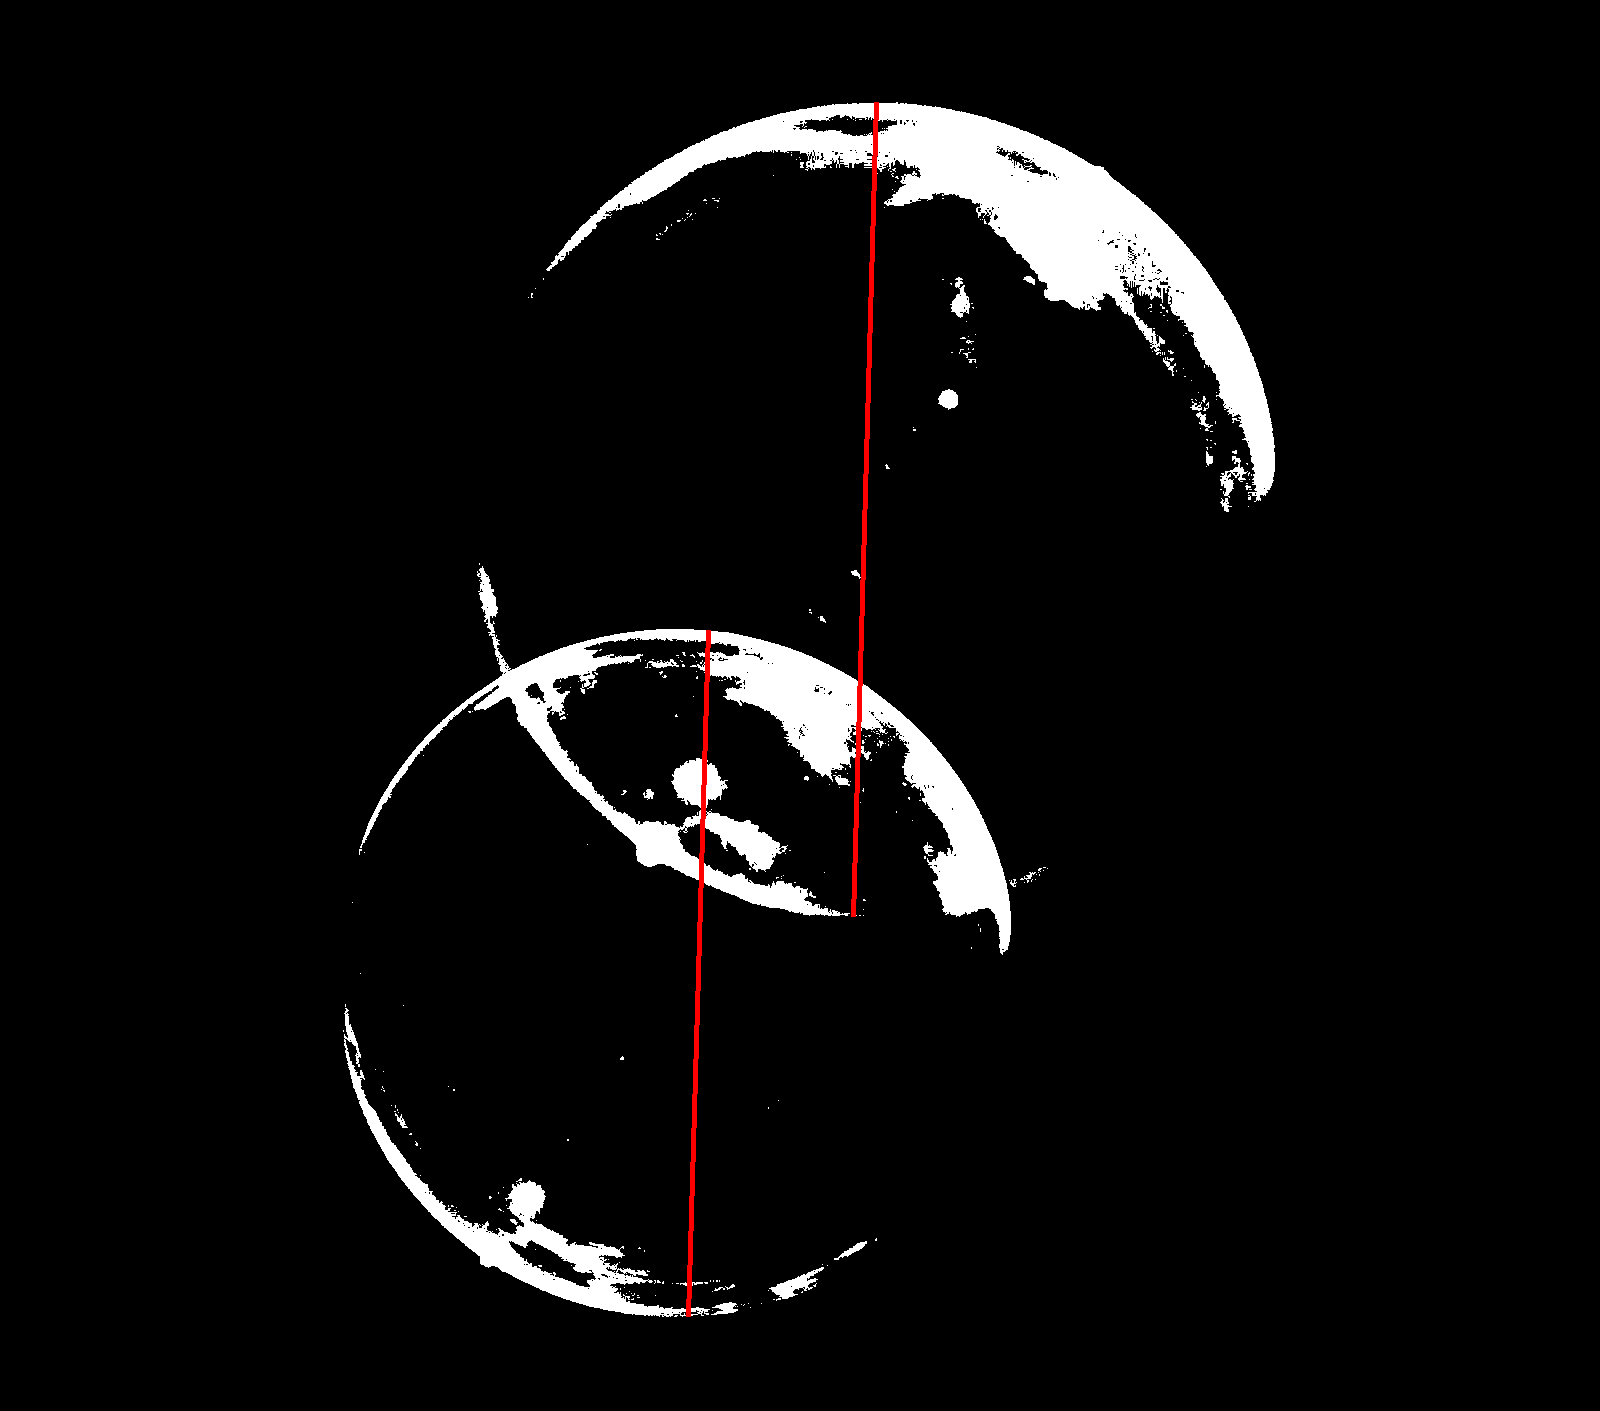

In [29]:
draw.line(line1, fill='red', width=5)
draw.line(line2, fill='red', width=5)
del draw
image